In [8]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
tfd = tfp.distributions
tfb = tfp.bijectors
vi = tfp.vi

import matplotlib.pyplot as plt
from bakeoff.TensorFlow_Prob.run_tfp import make_conditioned_lp
from tqdm.notebook import tqdm

In [9]:
mu_prior, sigma_prior = 0, 10
sigma_like = 1.0
max_iters = 100_000


DATA = True
if DATA:
    np.random.seed(0)
    data = np.random.normal(
        loc=mu_prior,
        scale=sigma_prior,
        size=100).astype(np.float32)


    true_mu_post = (sigma_like**2 * mu_prior + sigma_prior**2 * data.mean()) / (sigma_like**2 + sigma_prior**2)
    true_sigma_post = np.sqrt(1 / (1/sigma_prior**2 + 100/sigma_like**2))

else:
    data = []
    # compute true posteriors
    true_mu_post = mu_prior
    true_sigma_post = sigma_prior

target_log_prob_fn = make_conditioned_lp(
  prior_dist = tfd.Normal(mu_prior, sigma_prior),
  likelihood_dist = lambda z: tfd.Normal(z, sigma_like),
  x = data
)


In [ ]:
def run_restart(seed):
    q_z_single = tfp.experimental.vi.build_factored_surrogate_posterior(
        event_shape = (),
        bijector=tfb.Identity()
    )
    q_z_multiple = tfp.experimental.vi.build_factored_surrogate_posterior(
        event_shape = (),
        bijector=tfb.Identity()
    )

    def trace_fn_single(traceable_quantities):
        return q_z_single.distribution.loc, q_z_single.distribution.scale

    def trace_fn_multiple(traceable_quantities):
        return q_z_multiple.distribution.loc, q_z_multiple.distribution.scale

    single_sample_losses = tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn,
        seed=seed,
        surrogate_posterior=q_z_single,
        trainable_variables=q_z_single.trainable_variables,
        optimizer=tf.optimizers.Adam(),#learning_rate=0.01, epsilon=1e-8),
        trace_fn= trace_fn_single,
        num_steps=max_iters,
        jit_compile=True
        )
    multi_sample_losses = tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn,
        seed=seed+1000,
        surrogate_posterior=q_z_multiple,
        trainable_variables=q_z_multiple.trainable_variables,
        optimizer=tf.optimizers.Adam(),
        trace_fn= trace_fn_multiple,
        num_steps=max_iters,
        sample_size=100,
        jit_compile=True)
    return single_sample_losses, multi_sample_losses

In [17]:
results = []
for i in tqdm(range(100)):
    result = run_restart(i)
    results.append(result)

  0%|          | 0/100 [00:00<?, ?it/s]

2026-03-10 18:29:38.303615: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:108] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. fit_surrogate_posterior/sanitize_seed/seed
I0000 00:00:1773181778.813316  900748 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


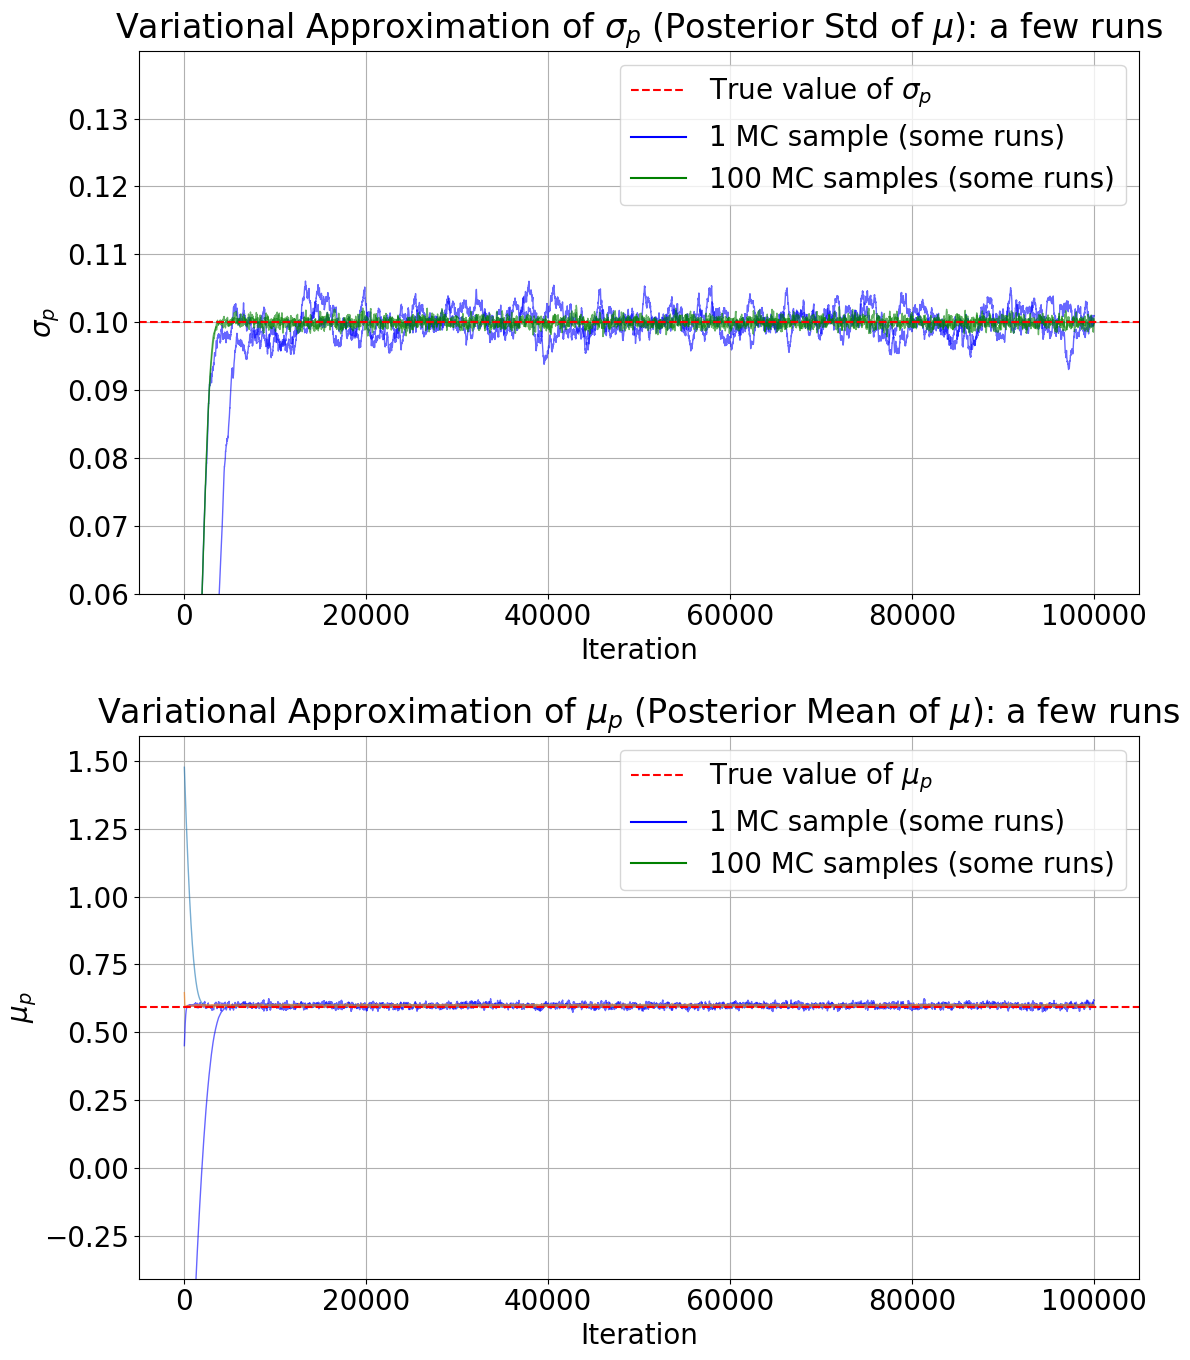

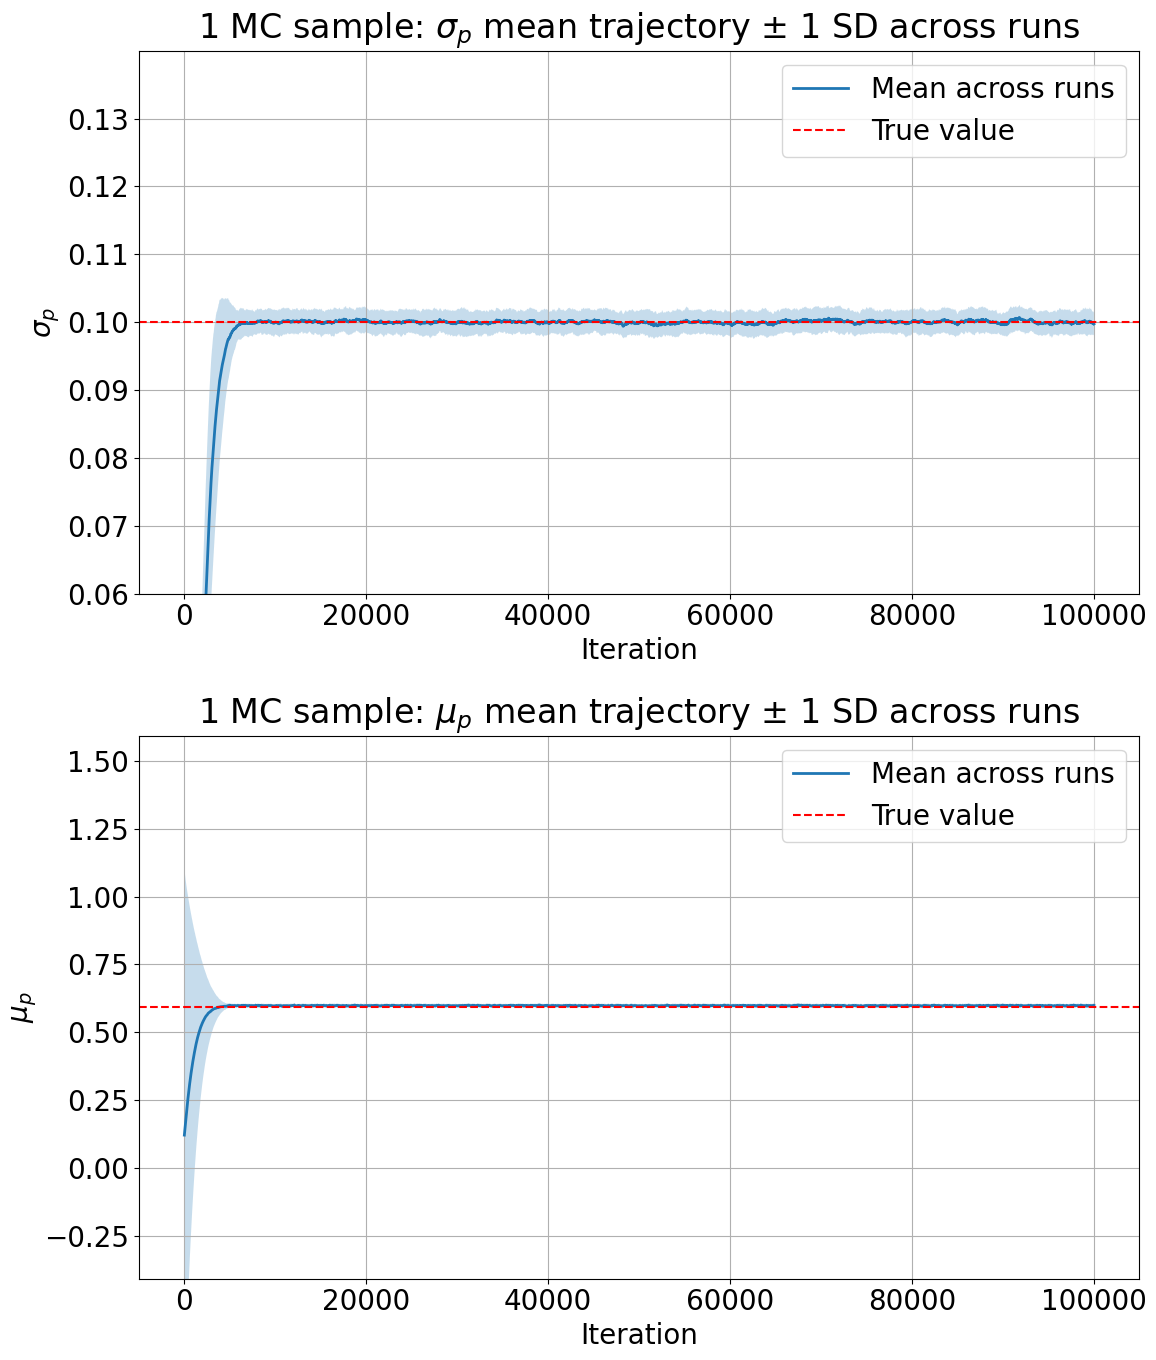

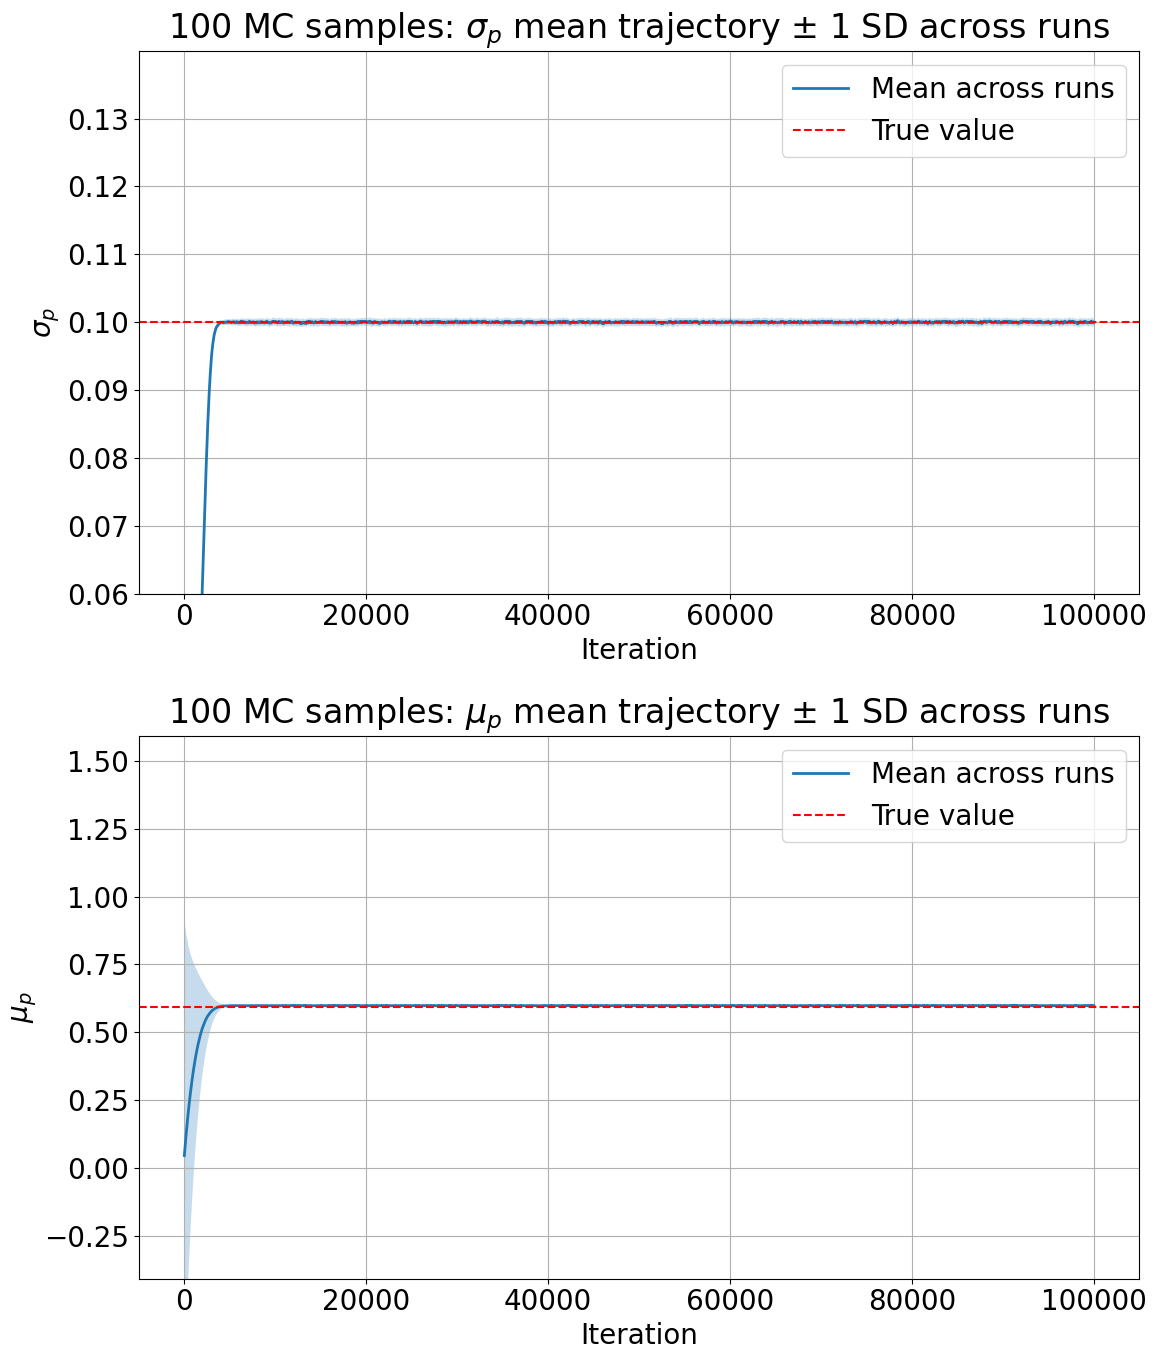

In [18]:
plt.rcParams.update({'font.size': 20})

# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []

for single_tracker, multi_tracker in results:
    single_means.append(single_tracker[0])
    single_stds.append(single_tracker[1])
    multi_means.append(multi_tracker[0])
    multi_stds.append(multi_tracker[1])

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
x = np.arange(T)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(true_sigma_post, color='red', linestyle='--', label=r'True value of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(true_sigma_post * 0.6, true_sigma_post * 1.4)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(true_mu_post, color='red', linestyle='--', label=r'True value of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(true_mu_post - 1, true_mu_post + 1)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='True value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, true_sigma_post,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(true_sigma_post * 0.6, true_sigma_post * 1.4)

plot_mean_band(
    axs[1], x, single_means, true_mu_post,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(true_mu_post - 1, true_mu_post + 1)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, true_sigma_post,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(true_sigma_post * 0.6, true_sigma_post * 1.4)

plot_mean_band(
    axs[1], x, multi_means, true_mu_post,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(true_mu_post - 1, true_mu_post + 1)

plt.tight_layout()
plt.show()

['AbsoluteValue', 'Ascending', 'AutoCompositeTensorBijector', 'AutoregressiveNetwork', 'BatchNormalization', 'Bijector', 'Blockwise', 'Chain', 'CholeskyOuterProduct', 'CholeskyToInvCholesky', 'Composition', 'CorrelationCholesky', 'Cumsum', 'DiscreteCosineTransform', 'Exp', 'Expm1', 'FFJORD', 'FillScaleTriL', 'FillTriangular', 'FrechetCDF', 'GeneralizedExtremeValueCDF', 'GeneralizedPareto', 'Glow', 'GlowDefaultExitNetwork', 'GlowDefaultNetwork', 'GompertzCDF', 'GumbelCDF', 'Householder', 'Identity', 'Inline', 'Invert', 'IteratedSigmoidCentered', 'JointMap', 'KumaraswamyCDF', 'LambertWTail', 'Log', 'Log1p', 'MaskedAutoregressiveFlow', 'MatrixInverseTriL', 'MatvecLU', 'MoyalCDF', 'NormalCDF', 'Pad', 'Permute', 'Power', 'PowerTransform', 'RationalQuadraticSpline', 'RayleighCDF', 'RealNVP', 'Reciprocal', 'Reshape', 'Restructure', 'Scale', 'ScaleMatvecDiag', 'ScaleMatvecLU', 'ScaleMatvecLinearOperator', 'ScaleMatvecLinearOperatorBlock', 'ScaleMatvecTriL', 'Shift', 'ShiftedGompertzCDF', 'Sigm